# ADMM Residuals Plotting

This notebook plots primal and dual residuals from ADMM iteration output files.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def parse_admm_file(filename):
    """
    Parse ADMM output file and extract iteration data.
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines and "τ is doubled" messages
        if not line or 'τ is doubled' in line:
            continue
        
        # Try to parse the line as a data row
        # Format: "  73  8.91e+01  4.755e+05  7.899e+03  3.760e+02  7.878e+03  1.220e+03"
        parts = line.split()
        
        if len(parts) >= 5:
            try:
                # Column 0: iteration, Column 2: objective, Column 3: primal residual, Column 4: dual residual
                iter_num = int(parts[0])
                # Handle 'inf' for objective
                obj_str = parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                primal = float(parts[3])
                dual = float(parts[4])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
            except (ValueError, IndexError):
                # Skip lines that don't match the expected format
                continue
    
    return np.array(iterations), np.array(objectives), np.array(primal_residuals), np.array(dual_residuals)

## Configuration

Specify the path to your ADMM output file:

In [23]:
# Update this path to point to your ADMM output file
SNR = "30"
num_views = "100"
rho = "2e-3"
regularization = "2e-2"
maxiter = "1000"
regularization_type = "l1"
Nx = 512
Nz = 512
Ny = 512
N_sphere = 100
save = False

input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_indicator_estimated_eps/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_indicator_estimated_eps_sinogram_snr{SNR}_ρ{rho}_regularization{regularization}_n_projection{num_views}_maxiter{maxiter}.txt"
# input_file_no_tau_decrease = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere100_indicator_estimated_eps_no_tau_decrease/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_indicator_estimated_eps_sinogram_snr{SNR}_ρ{rho}_regularization{regularization}_n_projection{num_views}_maxiter{maxiter}_no_tau_decrease.txt"
# input_file_gradually_tau_decrease = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere100_indicator_estimated_eps_gradually_tau_decrease/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_indicator_estimated_eps_sinogram_snr{SNR}_ρ{rho}_regularization{regularization}_n_projection{num_views}_maxiter{maxiter}_gradually_tau_decrease.txt"
# input_file_halve_tau_50_iterations = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere100_indicator_estimated_eps_halve_tau_50_iterations/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_indicator_estimated_eps_sinogram_snr{SNR}_ρ{rho}_regularization{regularization}_n_projection{num_views}_maxiter{maxiter}_halve_tau_50_iterations.txt"

input_file_pjadmm = "results/ct_mbirjax_3d_l1_pjadmm_indicator_estimated_eps_ρ2e-3_regularization2e-2_n_projection100_maxiter1000.txt"

In [24]:
input_file_padmm = f'results/ct_astra_3d_{regularization_type}_padmm_fbp_initial_indicator/{num_views}views_512x512x512_snr{SNR}_maxiter{maxiter}.txt'

## Parse Data

In [25]:
print(f"Parsing file: {input_file}")
# print(f"Parsing files: {input_file}, {input_file_no_tau_decrease}, {input_file_gradually_tau_decrease}, {input_file_halve_tau_50_iterations}")
iterations, objectives, primal_residuals, dual_residuals = parse_admm_file(input_file)
iterations_comparison, objectives_comparison, primal_residuals_comparison, dual_residuals_comparison = parse_admm_file(input_file_pjadmm)
# iterations_no_tau_decrease, objectives_no_tau_decrease, primal_residuals_no_tau_decrease, dual_residuals_no_tau_decrease = parse_admm_file(input_file_no_tau_decrease)
# iterations_gradually_tau_decrease, objectives_gradually_tau_decrease, primal_residuals_gradually_tau_decrease, dual_residuals_gradually_tau_decrease = parse_admm_file(input_file_gradually_tau_decrease)
# iterations_halve_tau_50_iterations, objectives_halve_tau_50_iterations, primal_residuals_halve_tau_50_iterations, dual_residuals_halve_tau_50_iterations = parse_admm_file(input_file_halve_tau_50_iterations)

iterations_padmm, objectives_padmm, primal_residuals_padmm, dual_residuals_padmm = parse_admm_file(input_file_padmm)

dual_residuals = dual_residuals / float(rho)
# dual_residuals_no_tau_decrease = dual_residuals_no_tau_decrease / float(rho)
# dual_residuals_gradually_tau_decrease = dual_residuals_gradually_tau_decrease / float(rho)
# dual_residuals_halve_tau_50_iterations = dual_residuals_halve_tau_50_iterations / float(rho)

# Moving average for smoother residual plots (adjust window to taste)
def moving_average(x, window):
    """Uniform moving average; same length as x (boundary uses partial window)."""
    return np.convolve(x, np.ones(window) / window, mode="same")

smooth_window = 100
primal_residuals_smooth = moving_average(primal_residuals, smooth_window)
primal_residuals_smooth_comparison = moving_average(primal_residuals_comparison, smooth_window)
primal_residuals_smooth_padmm = moving_average(primal_residuals_padmm, smooth_window)

dual_residuals_smooth = moving_average(dual_residuals, smooth_window)

Parsing file: results/semi_pjadmm_parallel_l1_fbp_noisy_sinogram_snr30_2_2_N_sphere100_indicator_estimated_eps/ct_mbirjax_3d_l1_semi_pjadmm_indicator_estimated_eps_sinogram_snr30_ρ2e-3_regularization2e-2_n_projection100_maxiter1000.txt


## Calculate Exact Objective Value

In [26]:
# from scico.examples import create_tangle_phantom, create_3d_foam_phantom
# from scico.functional import IsotropicTVNorm, L1Norm
# x_gt = create_3d_foam_phantom(im_shape=(Nz, Ny, Nx), N_sphere=N_sphere)
# if regularization_type == "tv":
#     true_regularization = IsotropicTVNorm(input_shape=(Nz, Ny, Nx))
# elif regularization_type == "l1":
#     true_regularization = L1Norm()


In [27]:
# true_objective = float(2e0) * true_regularization(x_gt)
# print(f"True objective: {true_objective}")

## Plot Residuals

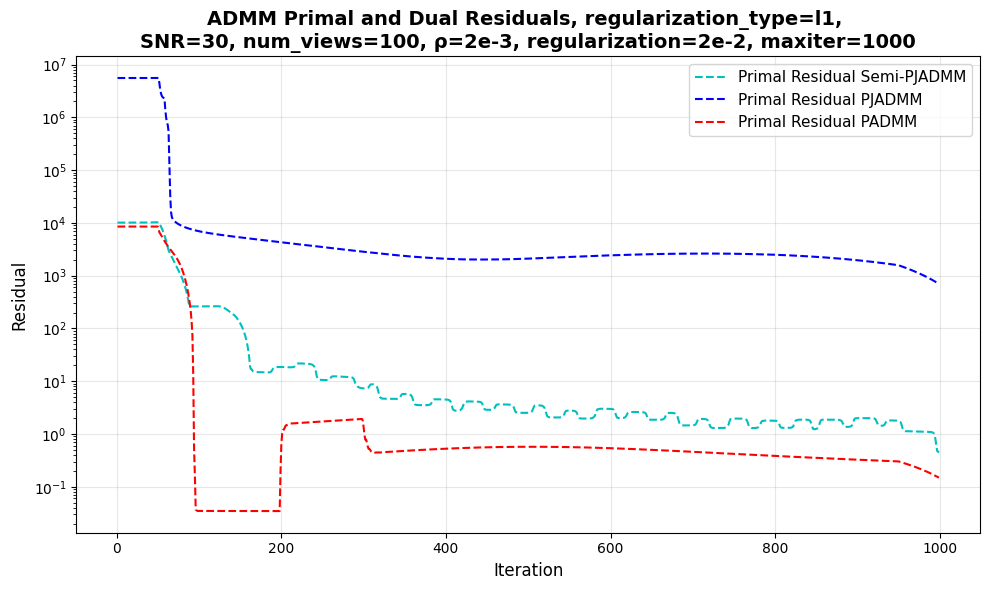

In [30]:
# Plot Residuals
plt.figure(figsize=(10, 6))

# plt.semilogy(iterations[1:], primal_residuals[1:], 'b-', label='Primal Residual', linewidth=1.5)
# plt.semilogy(iterations[1:], dual_residuals[1:], 'r-', label='Dual Residual', linewidth=1.5)
# plt.semilogy(iterations_no_tau_decrease[1:], primal_residuals_no_tau_decrease[1:], 'b--', label='Primal Residual (No τ Decrease)', linewidth=1.5)
# plt.semilogy(iterations_no_tau_decrease[1:], dual_residuals_no_tau_decrease[1:], 'r--', label='Dual Residual (No τ Decrease)', linewidth=1.5)
# plt.semilogy(iterations_gradually_tau_decrease[1:], primal_residuals_gradually_tau_decrease[1:], 'b*-', label='Primal Residual (Gradually τ Decrease)', linewidth=1.5)
# plt.semilogy(iterations_gradually_tau_decrease[1:], dual_residuals_gradually_tau_decrease[1:], 'r*-', label='Dual Residual (Gradually τ Decrease)', linewidth=1.5)
# plt.semilogy(iterations_halve_tau_50_iterations[1:], primal_residuals_halve_tau_50_iterations[1:], 'b-', label='Primal Residual (Halve τ 50 Iterations)', linewidth=1.5)
# plt.semilogy(iterations_halve_tau_50_iterations[1:], dual_residuals_halve_tau_50_iterations[1:], 'r-', label='Dual Residual (Halve τ 50 Iterations)', linewidth=1.5)

plt.semilogy(iterations[1:], primal_residuals_smooth[1:], 'c--', label='Primal Residual Semi-PJADMM', linewidth=1.5)

plt.semilogy(iterations_comparison[1:], primal_residuals_smooth_comparison[1:], 'b--', label='Primal Residual PJADMM', linewidth=1.5)


# plt.semilogy(iterations_padmm[1:], primal_residuals_padmm[1:], 'r--', label='Primal Residual PADMM', linewidth=1.5)
# plt.semilogy(iterations_padmm[1:], dual_residuals_padmm[1:], 'g--', label='Dual Residual PADMM', linewidth=1.5)

plt.semilogy(iterations_padmm[1:], primal_residuals_smooth_padmm[1:], 'r--', label='Primal Residual PADMM', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Primal and Dual Residuals, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

NameError: name 'true_objective' is not defined

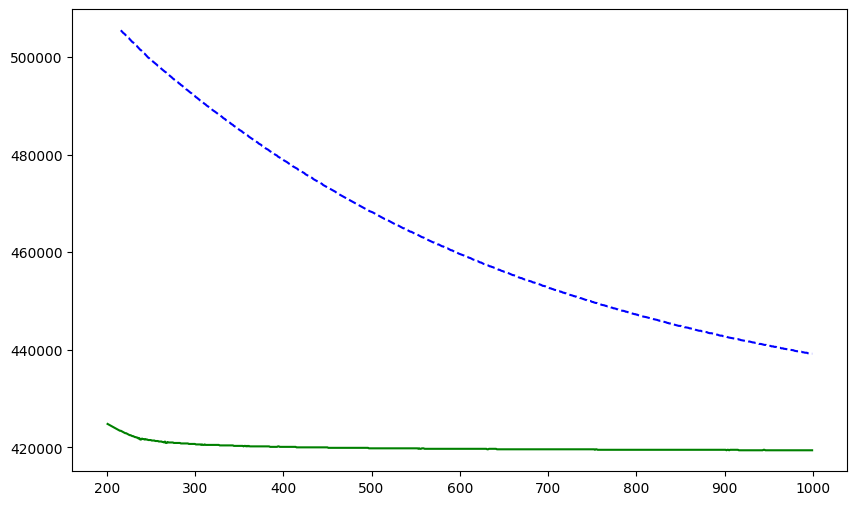

In [29]:
# Plot Objectives
plt.figure(figsize=(10, 6))
start_index = 200

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)
# valid_mask_no_tau = (objectives_no_tau_decrease != np.inf) & (objectives_no_tau_decrease > 0)
# valid_mask_gradually_tau = (objectives_gradually_tau_decrease != np.inf) & (objectives_gradually_tau_decrease > 0)
# valid_mask_halve_tau = (objectives_halve_tau_50_iterations != np.inf) & (objectives_halve_tau_50_iterations > 0)
valid_mask_padmm = (objectives_padmm != np.inf) & (objectives_padmm > 0)

plt.plot(iterations[valid_mask][start_index:], objectives[valid_mask][start_index:], 'g-', label='Objective', linewidth=1.5)
# plt.plot(iterations_no_tau_decrease[valid_mask_no_tau], objectives_no_tau_decrease[valid_mask_no_tau], 'g--', label='Objective (No τ Decrease)', linewidth=1.5)
# plt.plot(iterations_gradually_tau_decrease[valid_mask_gradually_tau], objectives_gradually_tau_decrease[valid_mask_gradually_tau], 'g*-', label='Objective (Gradually τ Decrease)', linewidth=1.5)
# plt.plot(iterations_halve_tau_50_iterations[valid_mask_halve_tau], objectives_halve_tau_50_iterations[valid_mask_halve_tau], 'b-', label='Objective (Halve τ 50 Iterations)', linewidth=1.5)
plt.plot(iterations_padmm[valid_mask_padmm][start_index:], objectives_padmm[valid_mask_padmm][start_index:], 'b--', label='Objective PADMM', linewidth=1.5)

# True objective
plt.axhline(y=true_objective, color='r', linestyle='--', label='True Objective', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Objective', fontsize=12)
plt.title(f'ADMM Objective, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_objectives_regularization_type{regularization_type}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()